In [1]:
! pip install rdkit

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 37.2/37.2 MB 51.5 MB/s eta 0:00:00


In [2]:
from rdkit import Chem
from rdkit.Chem import AllChem
from rdkit.DataStructs import TanimotoSimilarity
from rdkit.Chem.Scaffolds import MurckoScaffold
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from scipy.stats import ttest_ind
from rdkit.Chem import Descriptors
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler
from rdkit.Chem import Draw

In [3]:
compounds_cox2 = {
    #plant_compounds
    "Curcumin": "COC1=C(C=CC(=C1)/C=C/C(=O)CC(=O)/C=C/C2=CC(=C(C=C2)O)OC)O",
    "Apigenin": "C1=CC(=CC=C1C2=CC(=O)C3=C(C=C(C=C3O2)O)O)O",
    "Luteolin": "C1=CC(=C(C=C1C2=CC(=O)C3=C(C=C(C=C3O2)O)O)O)O",
    "6-Gingerol": "CCCCC[C@@H](CC(=O)CCC1=CC(=C(C=C1)O)OC)O",

    #endophyte_compounds
    "Tanzawaic Acid A": "C[C@H]1C[C@H](C2=C(C1)C=CC(=C2/C=C/C=C/C(=O)O)C)C",
    "Emodin": "CC1=CC2=C(C(=C1)O)C(=O)C3=C(C2=O)C=C(C=C3O)O",
    "Pestacin": "CC1=CC2=C(C(OC2)C3=C(C=CC=C3O)O)C(=C1)O",
    "Alternariol": "CC1=CC(=CC2=C1C3=C(C(=CC(=C3)O)O)C(=O)O2)O"

}

In [4]:
fps = {}

for name, smile in compounds_cox2.items():
    mol = Chem.MolFromSmiles(smile)
    fp = AllChem.GetMorganFingerprintAsBitVect(
        mol,
        radius=2,
        nBits=2048
    )
    fps[name] = fp

[22:44:03] DEPRECATION WARNING: please use MorganGenerator
[22:44:03] DEPRECATION WARNING: please use MorganGenerator
[22:44:03] DEPRECATION WARNING: please use MorganGenerator
[22:44:03] DEPRECATION WARNING: please use MorganGenerator
[22:44:03] DEPRECATION WARNING: please use MorganGenerator
[22:44:03] DEPRECATION WARNING: please use MorganGenerator
[22:44:03] DEPRECATION WARNING: please use MorganGenerator
[22:44:03] DEPRECATION WARNING: please use MorganGenerator


In [5]:
names= list(compounds_cox2.keys())

similarity_matrix = []

for i in names:
    row = []

    for j in names:
        sim = TanimotoSimilarity(
            fps[i],
            fps[j]
        )
        row.append(round(sim, 2))

    similarity_matrix.append(row)

df = pd.DataFrame(
    similarity_matrix,
    index=names,
    columns=names
)

df

,Curcumin,Apigenin,Luteolin,6-Gingerol,Tanzawaic Acid A,Emodin,Pestacin,Alternariol
Curcumin,1.00,0.15,0.16,0.35,0.18,0.16,0.15,0.15
Apigenin,0.15,1.00,0.78,0.12,0.08,0.24,0.15,0.41
Luteolin,0.16,0.78,1.00,0.13,0.07,0.23,0.14,0.39
6-Gingerol,0.35,0.12,0.13,1.00,0.11,0.13,0.12,0.12
Tanzawaic Acid A,0.18,0.08,0.07,0.11,1.00,0.10,0.18,0.11
Emodin,0.16,0.24,0.23,0.13,0.10,1.00,0.23,0.30
Pestacin,0.15,0.15,0.14,0.12,0.18,0.23,1.00,0.17
Alternariol,0.15,0.41,0.39,0.12,0.11,0.30,0.17,1.00


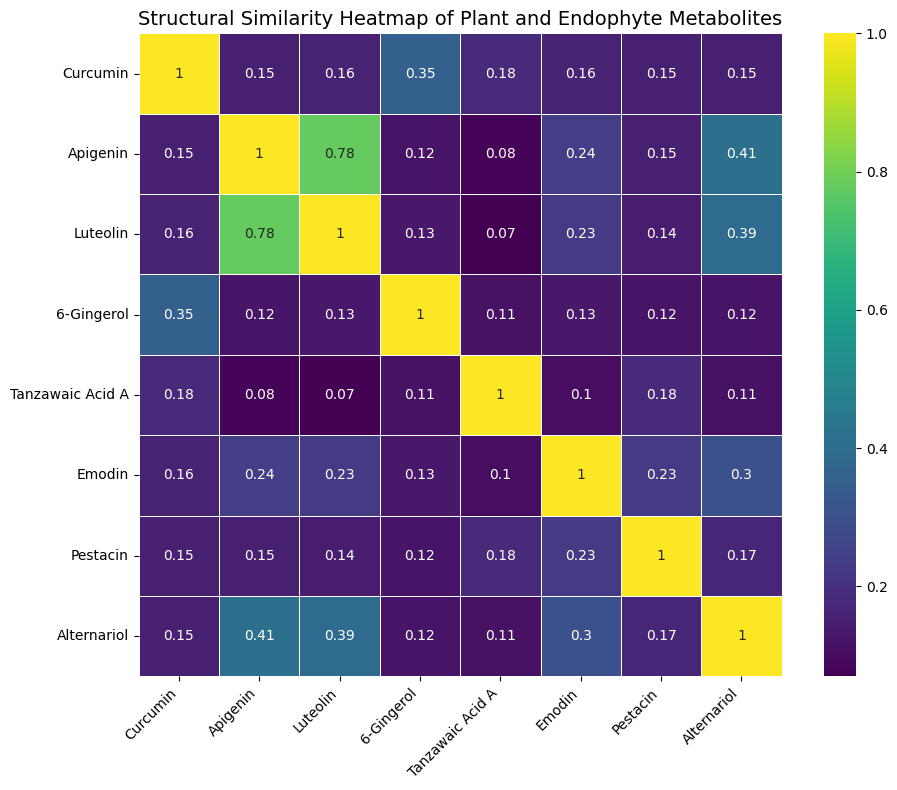

In [6]:
plt.figure(figsize=(10,8))

sns.heatmap(
    df,
    annot=True,
    cmap="viridis",
    linewidths=0.5,
    square=True
)

plt.title(
    "Structural Similarity Heatmap of Plant and Endophyte Metabolites",
    fontsize=14
)

plt.xticks(rotation=45, ha='right')
plt.yticks(rotation=0)

plt.tight_layout()

plt.savefig(
    "structural_similarity_heatmap.png",
    dpi=300,
    bbox_inches='tight'
)

plt.show()

In [7]:
# COX-2
plant_cox2 = [-8.6, -8.6, -8.2, -8.0]
endo_cox2 = [-9.0, -8.7, -8.5, -7.8]

print("COX-2")
print("Plant Mean:", np.mean(plant_cox2))
print("Endophyte Mean:", np.mean(endo_cox2))

t_stat, p_val = ttest_ind(plant_cox2, endo_cox2)

print("P-value:", p_val)

COX-2
Plant Mean: -8.35
Endophyte Mean: -8.5
P-value: 0.6301830967849156


In [8]:
descriptor_list = []

for name, smile in compounds_cox2.items():
    mol = Chem.MolFromSmiles(smile)

    descriptor_list.append([
        name,
        Descriptors.MolWt(mol),
        Descriptors.MolLogP(mol),
        Descriptors.NumHDonors(mol),
        Descriptors.NumHAcceptors(mol),
        Descriptors.TPSA(mol)
    ])

desc_df = pd.DataFrame(
    descriptor_list,
    columns=["Compound","MW","LogP","HDonors","HAcceptors","TPSA"]
)

In [9]:
features = desc_df.iloc[:,1:]

scaled = StandardScaler().fit_transform(features)

In [10]:
pca = PCA(n_components=2)
pca_result = pca.fit_transform(scaled)

desc_df["PC1"] = pca_result[:,0]
desc_df["PC2"] = pca_result[:,1]

In [11]:
desc_df["Category"] = [
    "Plant","Plant","Plant","Plant",
    "Endophyte","Endophyte","Endophyte","Endophyte"
]

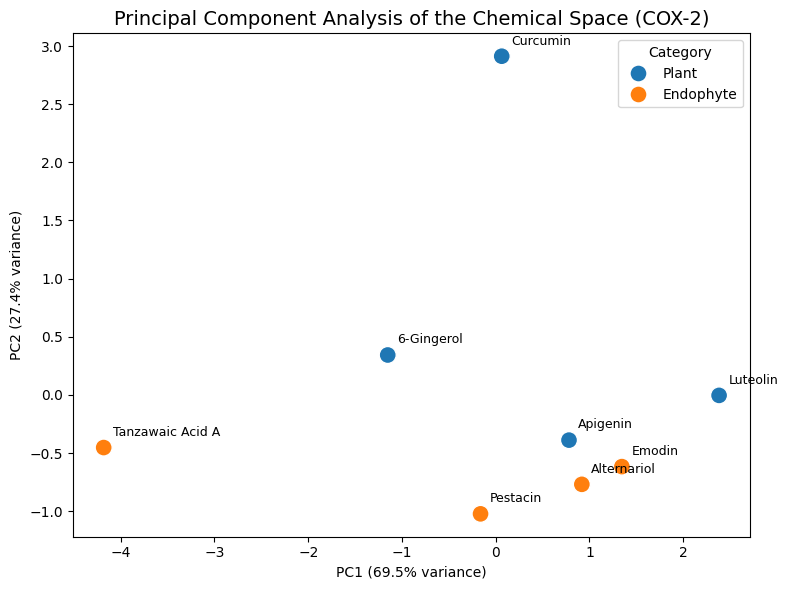

In [12]:
plt.figure(figsize=(8,6))

sns.scatterplot(
    x='PC1',
    y='PC2',
    hue='Category',
    data=desc_df,
    s=150
)

for i in range(len(desc_df)):
    plt.text(
        desc_df['PC1'][i] + 0.1,
        desc_df['PC2'][i] + 0.1,
        desc_df['Compound'][i],
        fontsize=9
    )

plt.title(
    "Principal Component Analysis of the Chemical Space (COX-2)",
    fontsize=14
)

plt.xlabel(f"PC1 ({pca.explained_variance_ratio_[0]*100:.1f}% variance)")
plt.ylabel(f"PC2 ({pca.explained_variance_ratio_[1]*100:.1f}% variance)")

plt.tight_layout()

plt.savefig(
    "PCA_chemical_space.png",
    dpi=300,
    bbox_inches='tight'
)

plt.show()